🚀 DAY 2

🧠Step 1 – Check Data Types

In this step, I examined the structure of the dataset using df.info() to understand the data types of each feature. Identifying whether a column is numerical (int64, float64) or categorical (object) is essential before applying any machine learning model.

Machine learning algorithms require numerical input, so detecting categorical variables early helps in planning appropriate encoding techniques such as Label Encoding or One-Hot Encoding. Additionally, this step helps verify the total number of entries and check for missing values in each column.

Understanding data types ensures proper preprocessing, prevents modeling errors, and builds a strong foundation for feature engineering and model training.

In [1]:
import pandas as pd

df = pd.read_csv("../data/student-mat.csv", sep=";")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

Machine learning models cannot understand text like:

"male"
"female"
"yes"
"no"

We must convert them into numbers.

🧠 Step 2 – Identify Categorical Columns

In [3]:
df.select_dtypes(include=['object', 'string']).columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

Step 3 – Encode Categorical Data

We convert text → numbers.

Method 1: Label Encoding (Simple)

📌 What is Label Encoding?

Label Encoding is a technique used to convert categorical text data into numerical form.

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])
print(df.head())

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         6   5   6   6  
1       5         3      3     1     1       3         4   5   5   6  
2       4         3      2     2     3       3        10   7   8  10  
3       3         2      2     1     1       5         2  15  14  15  
4       4         3      2     1     2       5         4   6  10  10  

[5 rows x 33 columns]


Example:

Before:
sex
[F,M]

After:
sex
[0,1]


Step 4 – Check Missing Values Again

In [8]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Step 5 – Correlation Check

In [4]:
import pandas as pd

df = pd.read_csv("../data/student-mat.csv", sep=";")   # replace with your file name
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


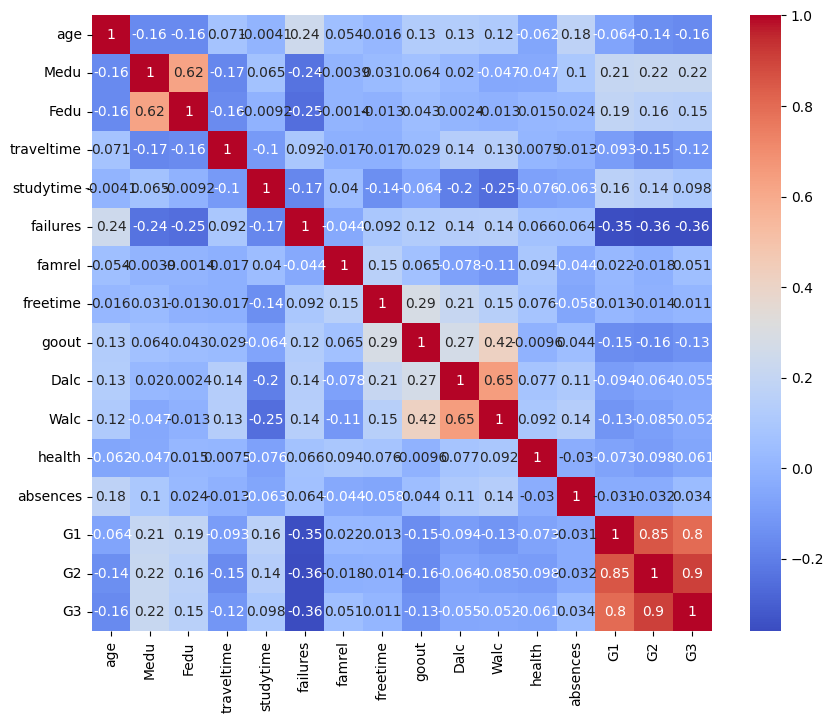

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.show()

coolwarm means:

Blue → negative correlation

Red → positive correlation

White → near zero

What is correlation in simple words?

Correlation is a statistical measure showing how two variables change together, indicating the strength and direction of their relationship

(e.g., both increase, one increases while the other decreases, or no consistent link), but it does not prove causation. It's measured by a coefficient (r) from -1 to +1, where +1 is perfect positive, -1 is perfect negative, and 0 is no linear relationship, showing if variables move together.  
